# U-Net CNN for brain tumor segmentation

### Import libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import glob
import os
from sklearn.preprocessing import MinMaxScaler
from skimage.transform import rotate
import matplotlib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import cv2
import torch.optim as optim
from collections import defaultdict
import csv

# Input data files are available in the read-only "../input/" directory
# List all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

### Load data from BRaTS

In [2]:
all_data_path = "/kaggle/input/brats20-dataset-training-validation" 
print(os.listdir(all_data_path))

['BraTS2020_ValidationData', 'BraTS2020_TrainingData']


In [3]:
data_path = "/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
patient = "BraTS20_Training_025"

print("Example patient folder:", patient)
print("Files inside:", os.listdir(os.path.join(data_path, patient)))

Example patient folder: BraTS20_Training_025
Files inside: ['BraTS20_Training_025_t1ce.nii', 'BraTS20_Training_025_flair.nii', 'BraTS20_Training_025_seg.nii', 'BraTS20_Training_025_t2.nii', 'BraTS20_Training_025_t1.nii']


In [7]:
import shutil

source = '/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_025'
destination = '/kaggle/working/BraTS20_Training_025'

shutil.copytree(source, destination)

'/kaggle/working/BraTS20_Training_025'

In [8]:
!zip -r /kaggle/working/BraTS20_Training_025.zip /kaggle/working/BraTS20_Training_025

  adding: kaggle/working/BraTS20_Training_025/ (stored 0%)
  adding: kaggle/working/BraTS20_Training_025/BraTS20_Training_025_seg.nii (deflated 100%)
  adding: kaggle/working/BraTS20_Training_025/BraTS20_Training_025_t2.nii (deflated 90%)
  adding: kaggle/working/BraTS20_Training_025/BraTS20_Training_025_flair.nii (deflated 91%)
  adding: kaggle/working/BraTS20_Training_025/BraTS20_Training_025_t1ce.nii (deflated 90%)
  adding: kaggle/working/BraTS20_Training_025/BraTS20_Training_025_t1.nii (deflated 90%)


### Display example images

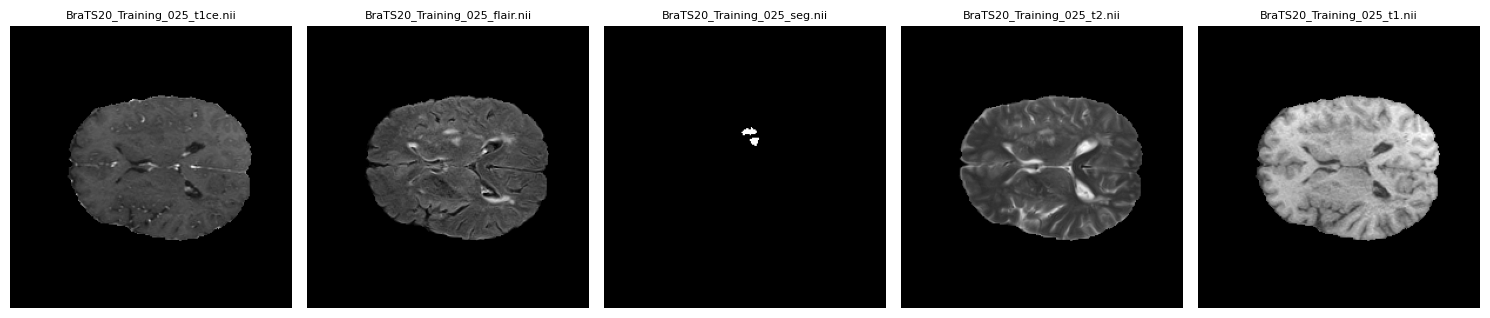

In [4]:
patient_path = os.path.join(data_path, patient)
files = os.listdir(patient_path)

num_files = len(files)
fig, axes = plt.subplots(1, num_files, figsize=(15, 5))

for i, file in enumerate(files):
    file_path = os.path.join(patient_path, file)
    img = nib.load(file_path)
    img_data = img.get_fdata()

    slice_num = img_data.shape[2] // 2
    # This will display slice 77
    slice_data = img_data[:, :, slice_num]

    axes[i].imshow(slice_data, cmap="gray", origin="lower")
    axes[i].set_title(file.replace(".nii.gz", ""), fontsize=8)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

1. Native (T1): This modality reveals the structure and composition of various tissue types in the brain. It's instrumental in identifying tumors, cysts, and other abnormalities.
2. Post-contrast T1-weighted (T1ce, also known as T1Gd): Similar to T1 images, but enhanced with a contrast agent (Gadolinium), which improves the visibility of abnormalities.
3. T2-weighted (T2): This modality highlights the fluid content within brain tissues.
4. T2-FLAIR (T2 - Fluid Attenuated Inversion Recovery): This technique suppresses the fluid signals, making it easier to identify lesions that may not be visible on T1 or T2 images. It is particularly useful for detecting lesions in the brain's white matter, which are challenging to spot with other scans.

### Scaling image arrays

In [5]:
scaler = MinMaxScaler()

# rescaling flair
test_image_flair = nib.load(data_path + '/BraTS20_Training_025/BraTS20_Training_025_flair.nii').get_fdata()
test_image_flair = scaler.fit_transform(test_image_flair.reshape(-1, test_image_flair.shape[-1])).reshape(test_image_flair.shape)
# rescaling t1
test_image_t1 = nib.load(data_path + '/BraTS20_Training_025/BraTS20_Training_025_t1.nii').get_fdata()
test_image_t1 = scaler.fit_transform(test_image_t1.reshape(-1, test_image_t1.shape[-1])).reshape(test_image_t1.shape)
# rescaling t1ce
test_image_t1ce = nib.load(data_path + '/BraTS20_Training_025/BraTS20_Training_025_t1ce.nii').get_fdata()
test_image_t1ce = scaler.fit_transform(test_image_t1ce.reshape(-1, test_image_t1ce.shape[-1])).reshape(test_image_t1ce.shape)
# rescaling t2
test_image_t2 = nib.load(data_path + '/BraTS20_Training_025/BraTS20_Training_025_t2.nii').get_fdata()
test_image_t2 = scaler.fit_transform(test_image_t2.reshape(-1, test_image_t2.shape[-1])).reshape(test_image_t2.shape)
# we will not rescale the mask
test_image_seg = nib.load(data_path + '/BraTS20_Training_025/BraTS20_Training_025_seg.nii').get_fdata()

Slice Number: 77


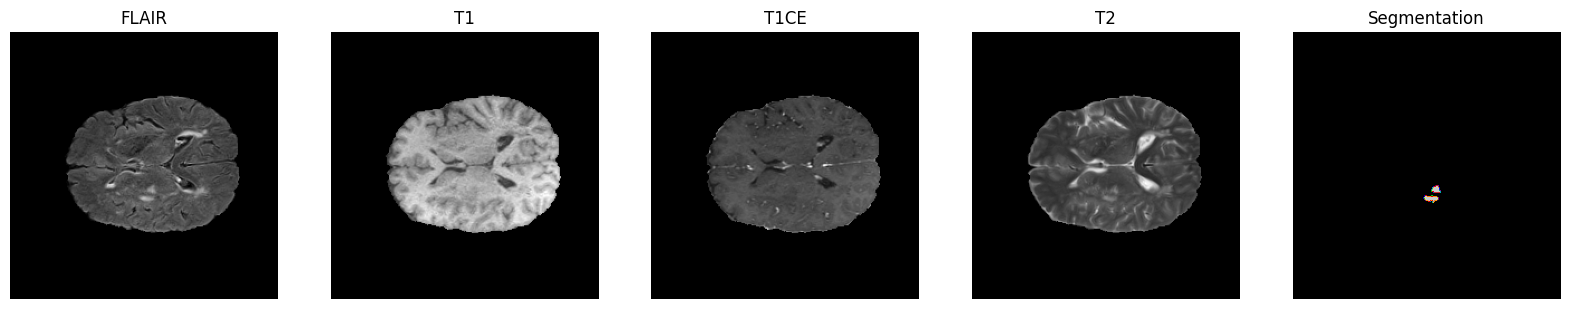

In [36]:
slice = 77
print("Slice Number: " + str(slice))

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

# Flair
axes[0].imshow(test_image_flair[:, :, slice], cmap='gray')
axes[0].set_title("FLAIR")
axes[0].axis("off")
# T1
axes[1].imshow(test_image_t1[:, :, slice], cmap='gray')
axes[1].set_title("T1")
axes[1].axis("off")
# T1ce
axes[2].imshow(test_image_t1ce[:, :, slice], cmap='gray')
axes[2].set_title("T1CE")
axes[2].axis("off")
# T2
axes[3].imshow(test_image_t2[:, :, slice], cmap='gray')
axes[3].set_title("T2")
axes[3].axis("off")
# Segmentation mask (discrete labels: 0, 1, 2, 4)
axes[4].imshow(test_image_seg[:, :, slice], cmap='nipy_spectral')
axes[4].set_title("Segmentation")
axes[4].axis("off")
plt.show()

### Displaying different views

Slice number: 77


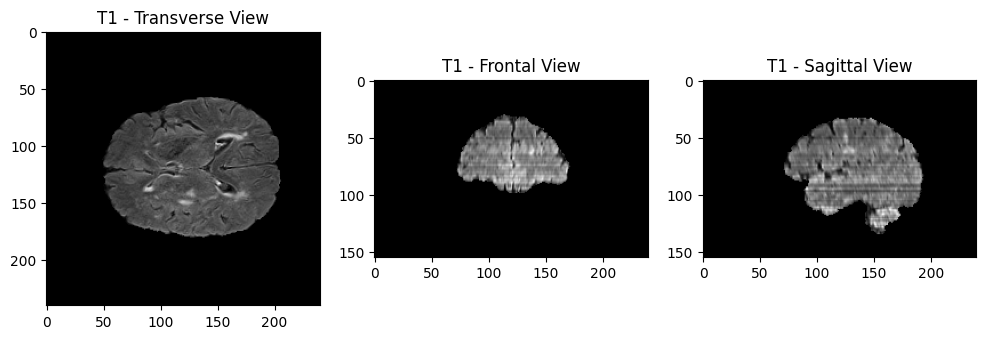

In [46]:
slice = 77

print("Slice number: " + str(slice))

plt.figure(figsize=(12, 8))

# Apply a 90° rotation with an automatic resizing, otherwise the display is less obvious to analyze
# T1 - Axial View
plt.subplot(1, 3, 1)
plt.imshow(test_image_flair[:,:,slice], cmap='gray')
plt.title('T1 - Axial View')
# T1 - Coronal View
plt.subplot(1, 3, 2)
plt.imshow(rotate(test_image_flair[:,slice,:], 90, resize=True), cmap='gray')
plt.title('T1 - Coronal View')
# T1 - Sagittal View
plt.subplot(1, 3, 3)
plt.imshow(rotate(test_image_flair[slice,:,:], 90, resize=True), cmap='gray')
plt.title('T1 - Sagittal View')
plt.show()

### Isolating segmentation classes


* Label 0: Not Tumor (NT) volume
* Label 1: Necrotic and non-enhancing tumor core (NCR/NET)
* Label 2: Peritumoral edema (ED)
* Label 3: Missing (No pixels in all the volumes contain label 3)
* Label 4: GD-enhancing tumor (ET)


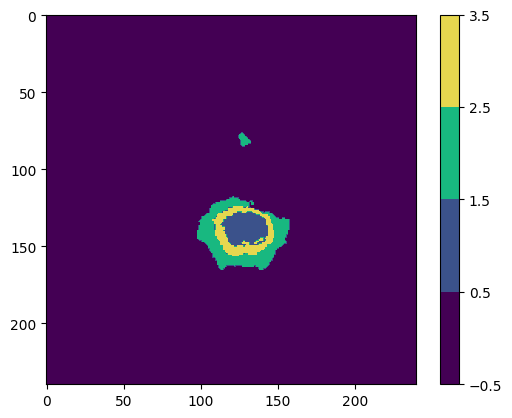

In [57]:
# Plotting the segmantation
cmap = matplotlib.colors.ListedColormap(['#440054', '#3b528b', '#18b880', '#e6d74f'])
norm = matplotlib.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

slice = 100

# plotting the 65th slice
plt.imshow(test_image_seg[:, :, slice], cmap=cmap, norm=norm)
plt.colorbar()
plt.show()

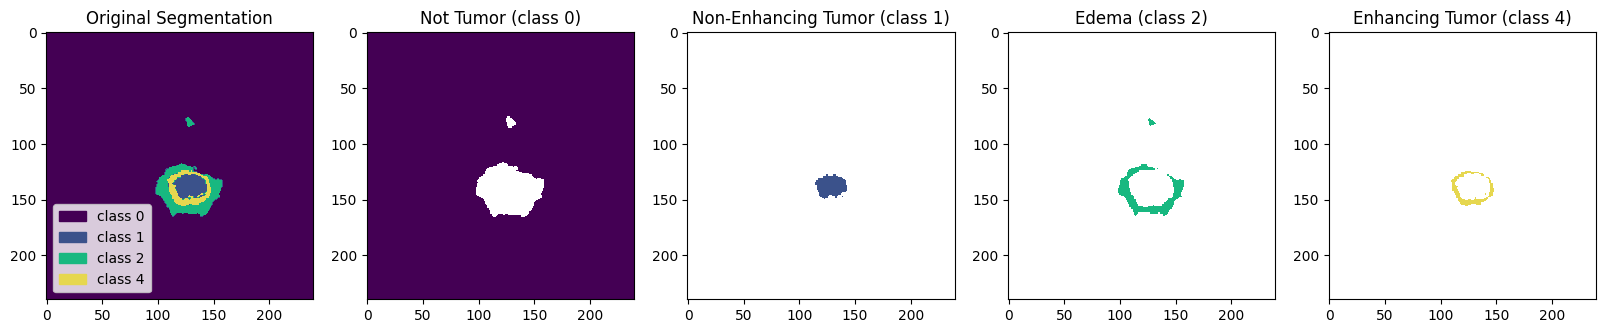

In [58]:
cmap = matplotlib.colors.ListedColormap(['#440054', '#3b528b', '#18b880', '#e6d74f'])
norm = matplotlib.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

# Isolation of class 0
seg_0 = test_image_seg.copy()
seg_0[seg_0 != 0] = np.nan

# Isolation of class 1
seg_1 = test_image_seg.copy()
seg_1[seg_1 != 1] = np.nan

# Isolation of class 2
seg_2 = test_image_seg.copy()
seg_2[seg_2 != 2] = np.nan

# Isolation of class 4
seg_4 = test_image_seg.copy()
seg_4[seg_4 != 4] = np.nan

# Define legend
class_names = ['class 0', 'class 1', 'class 2', 'class 4']
legend = [plt.Rectangle((0, 0), 1, 1, color=cmap(i), label=class_names[i]) for i in range(len(class_names))]

fig, ax = plt.subplots(1, 5, figsize=(20, 20))

ax[0].imshow(test_image_seg[:,:, slice], cmap=cmap, norm=norm)
ax[0].set_title('Original Segmentation')
ax[0].legend(handles=legend, loc='lower left')

ax[1].imshow(seg_0[:,:, slice], cmap=cmap, norm=norm)
ax[1].set_title('Not Tumor (class 0)')

ax[2].imshow(seg_1[:,:, slice], cmap=cmap, norm=norm)
ax[2].set_title('Non-Enhancing Tumor (class 1)')

ax[3].imshow(seg_2[:,:, slice], cmap=cmap, norm=norm)
ax[3].set_title('Edema (class 2)')

ax[4].imshow(seg_4[:,:, slice], cmap=cmap, norm=norm)
ax[4].set_title('Enhancing Tumor (class 4)')

plt.show()

### Splitting train, validation, and test sets

In [11]:
# # note: the validation data doesn't contain ground truth segmentation files?
# val_path = "/kaggle/input/brats20-dataset-training-validation/BraTS2020_ValidationData/MICCAI_BraTS2020_ValidationData"

# # using train data and validation folder, doesn't work!
# val_test_paths = [f.path for f in os.scandir(val_path) if f.is_dir()]
# train_paths = [f.path for f in os.scandir(data_path) if f.is_dir()]

# def path_list_to_ids(dirs):
#     x = []
#     for i in range(0,len(dirs)):
#         x.append(dirs[i][dirs[i].rfind('/')+1:])
#     return x

# val_test_ids = path_list_to_ids(val_test_paths)
# train_patients = path_list_to_ids(train_paths)
# val_patients, test_patients = train_test_split(val_test_ids,test_size=0.3)

In [6]:
# using train data folder only
train_dirs = [f.path for f in os.scandir(data_path) if f.is_dir()]

def pathListIntoIds(dirList):
    x = []
    for i in range(0,len(dirList)):
        x.append(dirList[i][dirList[i].rfind('/')+1:])
    return x

train_ids = pathListIntoIds(train_dirs);

train_test_ids, val_patients = train_test_split(train_ids,test_size=0.2)
train_patients, test_patients = train_test_split(train_test_ids,test_size=0.15)

In [7]:
print("Number of training patients:", len(train_patients))
print("Number of validation patients:", len(val_patients))
print("Number of test patients:", len(test_patients))

Number of training patients: 250
Number of validation patients: 74
Number of test patients: 45


### DataGenerator

We will use a Data Generator for image preprocessing, which includes several steps:
* Retrieve paths: Obtain the paths for the T1CE and FLAIR modalities (for complementary anatomical and tissue contrast information) and the ground truth segmentation.
* Load data: Load the selected slices (60-135) from these modalities and the corresponding segmentation.
* Create arrays: Form X arrays with the slices from T1CE and FLAIR, and y arrays with the segmentation slices.
* Class reassignment: Assign a value of 3 to all instances of 4 in the mask array to correct the missing class issue.

Additional preprocessing steps include:

* Axial plane: Use the axial plane for its square shape (240x240). This enables visualizing predictions across all planes without impact.
* One-Hot Encoding: Apply One-Hot Encoding to the y array to convert classes (0 to 3) into a numerical format suitable for neural networks, avoiding any implied hierarchy between classes. 

In [8]:
# Define seg-areas
SEGMENT_CLASSES = {
    0 : 'NOT tumor',
    1 : 'NECROTIC/CORE', # or NON-ENHANCING tumor CORE
    2 : 'EDEMA',
    3 : 'ENHANCING' # original 4 -> converted into 3
}

# Select Slices and Image Size
VOLUME_SLICES = 100
VOLUME_START_AT = 22 # first slice of volume that we will include
IMG_SIZE=128

Only loads T1CE and FLAIR:

In [9]:
TRAIN_DATASET_PATH = data_path

class BrainDataset(Dataset):
    'Generates data for PyTorch'
    def __init__(self, list_IDs, mode="train", dim=(IMG_SIZE, IMG_SIZE), n_channels=2, shuffle=True):
        'Initialization'
        self.dim = dim
        self.list_IDs = list_IDs
        self.mode = mode
        self.n_channels = n_channels
        self.shuffle = shuffle
        
        # Create expanded list of samples (each ID gets VOLUME_SLICES samples)
        self.samples = []
        for ID in list_IDs:
            for slice_idx in range(VOLUME_SLICES):
                self.samples.append((ID, slice_idx))
        
        if self.shuffle:
            np.random.shuffle(self.samples)

    def __len__(self):
        'Denotes the total number of samples'
        return len(self.samples)

    def __getitem__(self, idx):
        'Generate one sample of data'
        case_id, slice_idx = self.samples[idx]
        
        # Generate data
        X, y = self._load_sample(case_id, slice_idx)
        
        return X, y
    
    def _load_sample(self, case_id, slice_idx):
        'Loads and processes one sample'
        case_path = os.path.join(TRAIN_DATASET_PATH, case_id)

        # use the block below if we end up using the validation data
        # if self.mode == "train":
        #     case_path = os.path.join(TRAIN_DATASET_PATH, case_id)
        # else:
        #     case_path = os.path.join(VAL_DATASET_PATH, case_id)

        # Only loading FLAIR and T1CE
        # Load FLAIR
        data_path = os.path.join(case_path, f'{case_id}_flair.nii')
        flair = nib.load(data_path).get_fdata()
        # Load T1CE
        data_path = os.path.join(case_path, f'{case_id}_t1ce.nii')
        t1ce = nib.load(data_path).get_fdata()

        # Load segmentation
        seg_files = glob.glob(os.path.join(case_path, "*seg*.nii")) + \
        glob.glob(os.path.join(case_path, "*Segm*.nii"))
        if len(seg_files) == 0:
            raise FileNotFoundError(f"No segmentation file found in {case_path}")
        seg = nib.load(seg_files[0]).get_fdata()

        # Extract and resize the specific slice
        slice_pos = slice_idx + VOLUME_START_AT
        
        # Prepare input channels
        X = np.zeros((*self.dim, self.n_channels))
        X[:, :, 0] = cv2.resize(flair[:, :, slice_pos], self.dim)
        X[:, :, 1] = cv2.resize(t1ce[:, :, slice_pos], self.dim)
        
        # Prepare segmentation mask
        y_slice = seg[:, :, slice_pos]
        
        # Convert class 4 to class 3
        y_slice[y_slice == 4] = 3
        
        # Create one-hot encoding and resize
        y_one_hot = np.eye(4)[y_slice.astype(int)]  # Shape: (240, 240, 4)
        
        # Resize the one-hot mask
        y_resized = np.zeros((*self.dim, 4))
        for c in range(4):
            y_resized[:, :, c] = cv2.resize(y_one_hot[:, :, c], self.dim)

        # Normalize X
        X_max = np.max(X)
        if X_max > 0:
            X = X / X_max
        
        # Convert to PyTorch tensors and change dimension order to (C, H, W)
        X = torch.FloatTensor(X).permute(2, 0, 1)  # (4, IMG_SIZE, IMG_SIZE)
        y = torch.FloatTensor(y_resized).permute(2, 0, 1)  # (4, IMG_SIZE, IMG_SIZE)
        
        return X, y

This alternative data loader loads all four modalities into one stacked tensor (not using at the moment):

In [55]:
# TRAIN_DATASET_PATH = data_path

# class BrainDataset(Dataset):
#     'Generates data for PyTorch'
#     def __init__(self, list_IDs, mode="train", dim=(IMG_SIZE, IMG_SIZE), n_channels=2, shuffle=True):
#         'Initialization'
#         self.dim = dim
#         self.list_IDs = list_IDs
#         self.mode = mode
#         self.n_channels = n_channels
#         self.shuffle = shuffle
        
#         # Create expanded list of samples (each ID gets VOLUME_SLICES samples)
#         self.samples = []
#         for ID in list_IDs:
#             for slice_idx in range(VOLUME_SLICES):
#                 self.samples.append((ID, slice_idx))
        
#         if self.shuffle:
#             np.random.shuffle(self.samples)

#     def __len__(self):
#         'Denotes the total number of samples'
#         return len(self.samples)

#     def __getitem__(self, idx):
#         'Generate one sample of data'
#         case_id, slice_idx = self.samples[idx]
        
#         # Generate data
#         X, y = self._load_sample(case_id, slice_idx)
        
#         return X, y
    
#     def _load_sample(self, case_id, slice_idx):
#         'Loads and processes one sample'
#         case_path = os.path.join(TRAIN_DATASET_PATH, case_id)

#         # use the block below if we end up using the validation data
#         # if self.mode == "train":
#         #     case_path = os.path.join(TRAIN_DATASET_PATH, case_id)
#         # else:
#         #     case_path = os.path.join(VAL_DATASET_PATH, case_id)

#         # Load all 4 modalities
#         modalities = ["flair", "t1", "t1ce", "t2"]
#         X = np.zeros((*self.dim, len(modalities)))
#         for i, modality in enumerate(modalities):
#             data_path = os.path.join(case_path, f"{case_id}_{modality}.nii")
#             vol = nib.load(data_path).get_fdata()
#             slice_pos = slice_idx + VOLUME_START_AT
#             img = vol[:, :, slice_pos]
#             # Normalize each modality separately
#             if np.max(img) > 0:
#                 img = img / np.max(img)
#             X[:, :, i] = cv2.resize(img, self.dim)

#         # Load segmentation
#         seg_files = glob.glob(os.path.join(case_path, "*seg*.nii")) + \
#         glob.glob(os.path.join(case_path, "*Segm*.nii"))
#         if len(seg_files) == 0:
#             raise FileNotFoundError(f"No segmentation file found in {case_path}")
#         seg = nib.load(seg_files[0]).get_fdata()

#         # Extract and resize the specific slice
#         slice_pos = slice_idx + VOLUME_START_AT
#         # Prepare segmentation mask
#         y_slice = seg[:, :, slice_pos]
#         # Convert class 4 to class 3
#         y_slice[y_slice == 4] = 3
#         # Create one-hot encoding and resize
#         y_one_hot = np.eye(4)[y_slice.astype(int)]  # Shape: (240, 240, 4)
        
#         # Resize the one-hot mask
#         y_resized = np.zeros((*self.dim, 4))
#         # for c in range(4):
#         #     y_resized[:, :, c] = cv2.resize(y_one_hot[:, :, c], self.dim)
#         for c in range(4):
#             y_resized[:, :, c] = cv2.resize(y_one_hot[:, :, c], self.dim, interpolation=cv2.INTER_NEAREST)

        
#         # Convert to PyTorch tensors and change dimension order to (C, H, W)
#         X = torch.FloatTensor(X).permute(2, 0, 1)  # (4, IMG_SIZE, IMG_SIZE)
#         y = torch.FloatTensor(y_resized).permute(2, 0, 1)  # (4, IMG_SIZE, IMG_SIZE)
        
#         return X, y

In [10]:
# For individual slice processing (recommended for most cases):
train_dataset = BrainDataset(train_patients, mode="train", shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)

valid_dataset = BrainDataset(val_patients, mode="val",shuffle=False)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=4)

test_dataset = BrainDataset(test_patients, mode="test",shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

Preprocessing Steps Summary
* Data Generator: Utilized to process and send data to the neural network without overloading memory.
* Epoch Handling: For each epoch, the model processes 250 samples from the training dataset.
* Sample Analysis: Each sample consists of 150 slices (100 slices each from two modalities) resized to (128, 128).

Data Shapes:
* X Array: Shape (128, 128, 100, 2) for input images.
* Ground Truth (y): One-Hot encoded segmentation with shape (100, 128, 128, 4).

### Display sample slice and segmentation using DataGenerator

Only loads T1CE and FLAIR:

In [11]:
# Define a function to display one slice and its segmentation
def display_slice_and_segmentation(flair, t1ce, segmentation):
    fig, axes = plt.subplots(1, 3, figsize=(10, 5))

    axes[0].imshow(flair, cmap='gray')
    axes[0].set_title('Flair')
    axes[0].axis('off')

    axes[1].imshow(t1ce, cmap='gray')
    axes[1].set_title('T1CE')
    axes[1].axis('off')

    axes[2].imshow(segmentation) # Displaying segmentation
    axes[2].set_title('Segmentation')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

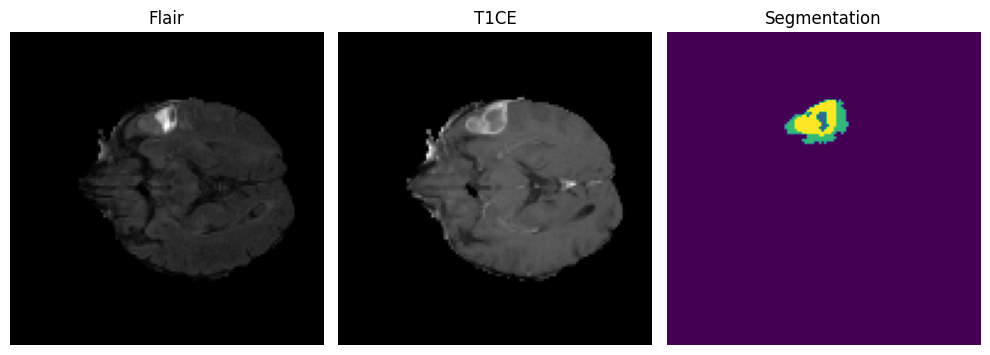

In [12]:
# Using individual slice dataset (BrainDataset)
# Get a specific sample directly from the dataset

sample_index = 100  # Choose your desired sample
X_sample, Y_sample = train_dataset[sample_index]

X_numpy = X_sample.permute(1, 2, 0).numpy()  # (IMG_SIZE, IMG_SIZE, 2)
Y_numpy = Y_sample.permute(1, 2, 0).numpy()  # (IMG_SIZE, IMG_SIZE, 4)

# Extract Flair and T1CE channels
slice_flair = X_numpy[:, :, 0]
slice_t1ce = X_numpy[:, :, 1]

# Convert one-hot encoded segmentation to categorical
slice_segmentation = np.argmax(Y_numpy, axis=-1)

# Display the slice and its segmentation
display_slice_and_segmentation(slice_flair, slice_t1ce, slice_segmentation)

This displays a slice and its segmentation using all 4 modalities:

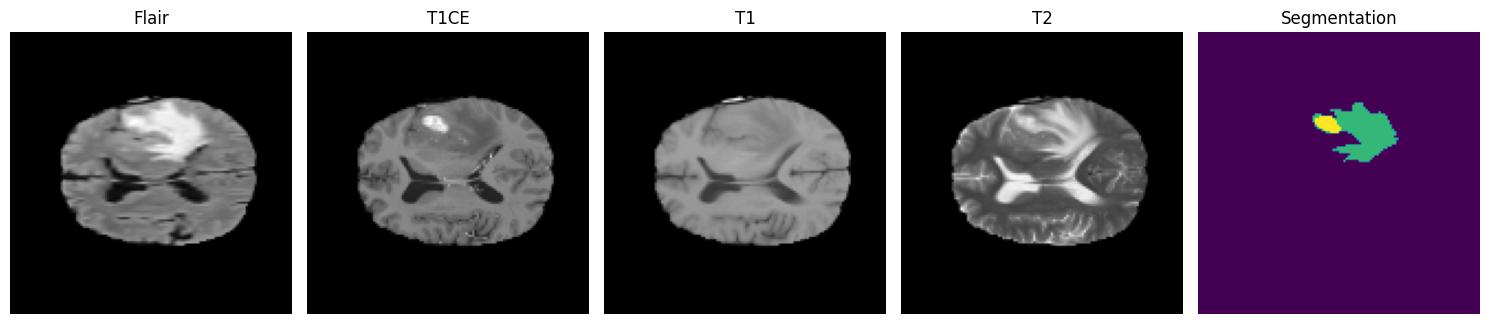

In [58]:
# # Define a function to display one slice and its segmentation
# def display_slice_and_segmentation(flair, t1ce, t1, t2, segmentation):
#     fig, axes = plt.subplots(1, 5, figsize=(15, 5))

#     axes[0].imshow(flair, cmap='gray')
#     axes[0].set_title('Flair')
#     axes[0].axis('off')

#     axes[1].imshow(t1ce, cmap='gray')
#     axes[1].set_title('T1CE')
#     axes[1].axis('off')

#     axes[2].imshow(t1, cmap='gray')
#     axes[2].set_title('T1')
#     axes[2].axis('off')

#     axes[3].imshow(t2, cmap='gray')
#     axes[3].set_title('T2')
#     axes[3].axis('off')

#     axes[4].imshow(segmentation) # Displaying segmentation
#     axes[4].set_title('Segmentation')
#     axes[4].axis('off')

#     plt.tight_layout()
#     plt.show()
    
# # Using individual slice dataset (BrainDataset)
# # Get a specific sample directly from the dataset

# sample_index = 100  # Choose your desired sample
# X_sample, Y_sample = train_dataset[sample_index]

# X_numpy = X_sample.permute(1, 2, 0).numpy()  # (IMG_SIZE, IMG_SIZE, 4)
# Y_numpy = Y_sample.permute(1, 2, 0).numpy()  # (IMG_SIZE, IMG_SIZE, 4)

# # Extract channels
# slice_flair = X_numpy[:, :, 0]
# slice_t1 = X_numpy[:, :, 1]
# slice_t1ce = X_numpy[:, :, 2]
# slice_t2 = X_numpy[:, :, 3]

# # Convert one-hot encoded segmentation to categorical
# slice_segmentation = np.argmax(Y_numpy, axis=-1)

# # Display the slice and its segmentation
# display_slice_and_segmentation(slice_flair, slice_t1ce, slice_t1, slice_t2, slice_segmentation)

### Loss function and evaluation metrics

We will be using Cross Entropy Loss. Alternatively, Dice Coefficient: Evaluates the similarity between predicted and ground truth segmentations.

In [13]:
def dice_coef(y_true, y_pred, smooth=1.0):
    """
    Calculate Dice coefficient for multi-class segmentation
    Args:
        y_true: Ground truth tensor of shape (batch_size, num_classes, height, width)
        y_pred: Predicted tensor of shape (batch_size, num_classes, height, width)
        smooth: Smoothing factor to avoid division by zero
    Returns:
        Average Dice coefficient across all classes
    """
    class_num = 4
    total_loss = 0.0
    
    for i in range(class_num):
        y_true_f = torch.flatten(y_true[:, i, :, :])
        y_pred_f = torch.flatten(y_pred[:, i, :, :])
        intersection = torch.sum(y_true_f * y_pred_f)
        loss = (2.0 * intersection + smooth) / (torch.sum(y_true_f) + torch.sum(y_pred_f) + smooth)
        total_loss += loss
    
    return total_loss / class_num

def dice_coef_necrotic(y_true, y_pred, epsilon=1e-6):
    """
    Calculate Dice coefficient for necrotic class (class 1)
    """
    intersection = torch.sum(torch.abs(y_true[:, 1, :, :] * y_pred[:, 1, :, :]))
    return (2.0 * intersection) / (torch.sum(torch.square(y_true[:, 1, :, :])) + 
                                  torch.sum(torch.square(y_pred[:, 1, :, :])) + epsilon)

def dice_coef_edema(y_true, y_pred, epsilon=1e-6):
    """
    Calculate Dice coefficient for edema class (class 2)
    """
    intersection = torch.sum(torch.abs(y_true[:, 2, :, :] * y_pred[:, 2, :, :]))
    return (2.0 * intersection) / (torch.sum(torch.square(y_true[:, 2, :, :])) + 
                                  torch.sum(torch.square(y_pred[:, 2, :, :])) + epsilon)

def dice_coef_enhancing(y_true, y_pred, epsilon=1e-6):
    """
    Calculate Dice coefficient for enhancing class (class 3)
    """
    intersection = torch.sum(torch.abs(y_true[:, 3, :, :] * y_pred[:, 3, :, :]))
    return (2.0 * intersection) / (torch.sum(torch.square(y_true[:, 3, :, :])) + 
                                  torch.sum(torch.square(y_pred[:, 3, :, :])) + epsilon)

Precision, sensitivity, and specificity:

In [14]:
# Computing Precision
def precision(y_true, y_pred, epsilon=1e-7):
    """
    Calculate precision across all classes
    """
    true_positives = torch.sum(torch.round(torch.clamp(y_true * y_pred, 0, 1)))
    predicted_positives = torch.sum(torch.round(torch.clamp(y_pred, 0, 1)))
    precision_val = true_positives / (predicted_positives + epsilon)
    return precision_val

# Computing Sensitivity (Recall)
def sensitivity(y_true, y_pred, epsilon=1e-7):
    """
    Calculate sensitivity (recall) across all classes
    """
    true_positives = torch.sum(torch.round(torch.clamp(y_true * y_pred, 0, 1)))
    possible_positives = torch.sum(torch.round(torch.clamp(y_true, 0, 1)))
    return true_positives / (possible_positives + epsilon)

# Computing Specificity
def specificity(y_true, y_pred, epsilon=1e-7):
    """
    Calculate specificity across all classes
    """
    true_negatives = torch.sum(torch.round(torch.clamp((1 - y_true) * (1 - y_pred), 0, 1)))
    possible_negatives = torch.sum(torch.round(torch.clamp(1 - y_true, 0, 1)))
    return true_negatives / (possible_negatives + epsilon)

### U-Net Convolutional Neural Network

We will use the U-Net architecture, a convolutional neural network (CNN) specifically designed for biomedical image segmentation. U-Net is particularly effective for segmenting regions of interest that are small and have complex shapes, such as tumors in MRI scans

In [15]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=4, dropout=0.5):
        super(UNet, self).__init__()
        
        # Encoder
        # Block 1
        self.conv1_1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.conv1_2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 2
        self.conv2_1 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv2_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 3
        self.conv3_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 4
        self.conv4_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Block 5 (Bottleneck)
        self.conv5_1 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv5_2 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.dropout = nn.Dropout2d(p=dropout)
        
        # Decoder
        # Block 6
        self.upconv6 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv6_1 = nn.Conv2d(512, 256, kernel_size=3, padding=1)  # 512 = 256 + 256 (concatenation)
        self.conv6_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        
        # Block 7
        self.upconv7 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv7_1 = nn.Conv2d(256, 128, kernel_size=3, padding=1)  # 256 = 128 + 128
        self.conv7_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        
        # Block 8
        self.upconv8 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv8_1 = nn.Conv2d(128, 64, kernel_size=3, padding=1)  # 128 = 64 + 64
        self.conv8_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        
        # Block 9
        self.upconv9 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv9_1 = nn.Conv2d(64, 32, kernel_size=3, padding=1)  # 64 = 32 + 32
        self.conv9_2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        
        # Output layer
        self.conv10 = nn.Conv2d(32, num_classes, kernel_size=1)
        
        # Initialize weights
        self._initialize_weights()
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        # Encoder
        # Block 1
        conv1 = F.relu(self.conv1_1(x))
        conv1 = F.relu(self.conv1_2(conv1))
        pool1 = self.pool1(conv1)
        
        # Block 2
        conv2 = F.relu(self.conv2_1(pool1))
        conv2 = F.relu(self.conv2_2(conv2))
        pool2 = self.pool2(conv2)
        
        # Block 3
        conv3 = F.relu(self.conv3_1(pool2))
        conv3 = F.relu(self.conv3_2(conv3))
        pool3 = self.pool3(conv3)
        
        # Block 4
        conv4 = F.relu(self.conv4_1(pool3))
        conv4 = F.relu(self.conv4_2(conv4))
        pool4 = self.pool4(conv4)
        
        # Block 5 (Bottleneck)
        conv5 = F.relu(self.conv5_1(pool4))
        conv5 = F.relu(self.conv5_2(conv5))
        conv5 = self.dropout(conv5)
        
        # Decoder
        # Block 6
        up6 = self.upconv6(conv5)
        merge6 = torch.cat([conv4, up6], dim=1)
        conv6 = F.relu(self.conv6_1(merge6))
        conv6 = F.relu(self.conv6_2(conv6))
        
        # Block 7
        up7 = self.upconv7(conv6)
        merge7 = torch.cat([conv3, up7], dim=1)
        conv7 = F.relu(self.conv7_1(merge7))
        conv7 = F.relu(self.conv7_2(conv7))
        
        # Block 8
        up8 = self.upconv8(conv7)
        merge8 = torch.cat([conv2, up8], dim=1)
        conv8 = F.relu(self.conv8_1(merge8))
        conv8 = F.relu(self.conv8_2(conv8))
        
        # Block 9
        up9 = self.upconv9(conv8)
        merge9 = torch.cat([conv1, up9], dim=1)
        conv9 = F.relu(self.conv9_1(merge9))
        conv9 = F.relu(self.conv9_2(conv9))
        
        # Output
        out = self.conv10(conv9)
        
        return out

In [16]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize model
model = UNet(in_channels=2, num_classes=4)
model = model.to(device)


# Print model summary (PyTorch equivalent of model.summary())
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model has {count_parameters(model):,} trainable parameters")

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # For categorical crossentropy
# Alternative: Use your custom DiceLoss
# criterion = DiceLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler (equivalent to ReduceLROnPlateau)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.2, 
    patience=2, 
    min_lr=1e-6, 
    verbose=True
)

# Create data loaders
train_dataset = BrainDataset(train_patients, mode="train",shuffle=True)
valid_dataset = BrainDataset(val_patients, mode="val",shuffle=False)

train_loader = DataLoader(
    train_dataset, 
    batch_size=8,  # Adjust based on your GPU memory
    shuffle=True, 
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

valid_loader = DataLoader(
    valid_dataset, 
    batch_size=8, 
    shuffle=False, 
    num_workers=4,
    pin_memory=True if torch.cuda.is_available() else False
)

# Training history storage
history = {
    'train_loss': [],
    'val_loss': [],
    'train_accuracy': [],
    'val_accuracy': [],
    'train_dice_coef': [],
    'val_dice_coef': [],
    'train_precision': [],
    'val_precision': [],
    'train_sensitivity': [],
    'val_sensitivity': [],
    'train_specificity': [],
    'val_specificity': [],
    'train_dice_necrotic': [],
    'val_dice_necrotic': [],
    'train_dice_edema': [],
    'val_dice_edema': [],
    'train_dice_enhancing': [],
    'val_dice_enhancing': [],
    'learning_rate': []
}

# CSV Logger equivalent
def log_to_csv(epoch, train_metrics, val_metrics, filepath='training.log'):
    """Log training metrics to CSV file"""
    file_exists = os.path.isfile(filepath)
    
    with open(filepath, 'a', newline='') as csvfile:
        fieldnames = ['epoch', 'lr'] + [f'train_{k}' for k in train_metrics.keys()] + [f'val_{k}' for k in val_metrics.keys()]
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        
        if not file_exists:
            writer.writeheader()
        
        row = {'epoch': epoch, 'lr': optimizer.param_groups[0]['lr']}
        row.update({f'train_{k}': v for k, v in train_metrics.items()})
        row.update({f'val_{k}': v for k, v in val_metrics.items()})
        writer.writerow(row)

Using device: cuda
Model has 7,759,908 trainable parameters


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [17]:
# Training function
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    all_metrics = defaultdict(list)
    
    for batch_idx, (X, y_true) in enumerate(train_loader):
        X, y_true = X.to(device), y_true.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        y_pred = model(X)
        
        # Calculate loss
        if isinstance(criterion, nn.CrossEntropyLoss):
            # Convert one-hot to class indices for CrossEntropyLoss
            y_true_indices = torch.argmax(y_true, dim=1)
            loss = criterion(y_pred, y_true_indices)
            # Convert predictions back to probabilities for metrics
            y_pred_probs = torch.softmax(y_pred, dim=1)
        else:
            # For custom losses like DiceLoss
            loss = criterion(y_pred, y_true)
            y_pred_probs = torch.softmax(y_pred, dim=1)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Accumulate loss
        running_loss += loss.item()
        
        # Calculate metrics
        with torch.no_grad():
            # Calculate accuracy
            pred_indices = torch.argmax(y_pred_probs, dim=1)
            true_indices = torch.argmax(y_true, dim=1)
            accuracy = (pred_indices == true_indices).float().mean()
            
            # Calculate other metrics
            batch_metrics = compute_all_metrics(y_true, y_pred_probs)
            batch_metrics['accuracy'] = accuracy.item()
            
            for key, value in batch_metrics.items():
                all_metrics[key].append(value)
        
        # Print progress
        if batch_idx % 100 == 0:
            print(f'Train Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.6f}')
    
    # Calculate average metrics
    avg_metrics = {key: np.mean(values) for key, values in all_metrics.items()}
    avg_loss = running_loss / len(train_loader)
    
    return avg_loss, avg_metrics

# Validation function
def validate_epoch(model, valid_loader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    all_metrics = defaultdict(list)
    
    with torch.no_grad():
        for X, y_true in valid_loader:
            X, y_true = X.to(device), y_true.to(device)
            
            # Forward pass
            y_pred = model(X)
            
            # Calculate loss
            if isinstance(criterion, nn.CrossEntropyLoss):
                y_true_indices = torch.argmax(y_true, dim=1)
                loss = criterion(y_pred, y_true_indices)
                y_pred_probs = torch.softmax(y_pred, dim=1)
            else:
                loss = criterion(y_pred, y_true)
                y_pred_probs = torch.softmax(y_pred, dim=1)
            
            running_loss += loss.item()
            
            # Calculate metrics
            pred_indices = torch.argmax(y_pred_probs, dim=1)
            true_indices = torch.argmax(y_true, dim=1)
            accuracy = (pred_indices == true_indices).float().mean()
            
            batch_metrics = compute_all_metrics(y_true, y_pred_probs)
            batch_metrics['accuracy'] = accuracy.item()
            
            for key, value in batch_metrics.items():
                all_metrics[key].append(value)
    
    avg_metrics = {key: np.mean(values) for key, values in all_metrics.items()}
    avg_loss = running_loss / len(valid_loader)
    
    return avg_loss, avg_metrics

### Train and save the model
We will pass our three callbacks to this method to be executed during the training process, which will last for 35 epochs.

In [18]:
# Utility functions for model evaluation
def compute_all_metrics(y_true, y_pred):
    """
    Compute all metrics at once
    
    Returns:
        Dictionary containing all computed metrics
    """
    metrics = {
        'dice_coef': dice_coef(y_true, y_pred).item(),
        'dice_necrotic': dice_coef_necrotic(y_true, y_pred).item(),
        'dice_edema': dice_coef_edema(y_true, y_pred).item(),
        'dice_enhancing': dice_coef_enhancing(y_true, y_pred).item(),
        'precision': precision(y_true, y_pred).item(),
        'sensitivity': sensitivity(y_true, y_pred).item(),
        'specificity': specificity(y_true, y_pred).item()
    }
    return metrics

# Example usage during training/validation
def evaluate_model(model, dataloader, device):
    """
    Evaluate model on a dataset and return average metrics
    """
    model.eval()
    all_metrics = {
        'dice_coef': [],
        'dice_necrotic': [],
        'dice_edema': [],
        'dice_enhancing': [],
        'precision': [],
        'sensitivity': [],
        'specificity': []
    }
    
    with torch.no_grad():
        for X, y_true in dataloader:
            X, y_true = X.to(device), y_true.to(device)
            
            # Get predictions
            y_pred = model(X)
            
            # Apply softmax if your model doesn't include it
            if not hasattr(model, 'softmax_applied'):
                y_pred = F.softmax(y_pred, dim=1)
            
            # Compute metrics for this batch
            batch_metrics = compute_all_metrics(y_true, y_pred)
            
            # Accumulate metrics
            for key, value in batch_metrics.items():
                all_metrics[key].append(value)
    
    # Compute average metrics
    avg_metrics = {key: sum(values) / len(values) for key, values in all_metrics.items()}
    
    return avg_metrics

In [19]:
# Training loop
num_epochs = 3
best_val_loss = float('inf')
best_model_path = 'best_model.pth'

print("Starting training...")
for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 50)
    
    # Train
    train_loss, train_metrics = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_metrics = validate_epoch(model, valid_loader, criterion, device)
    
    # Update learning rate
    scheduler.step(val_loss)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['learning_rate'].append(optimizer.param_groups[0]['lr'])
    
    for key in train_metrics:
        history[f'train_{key}'].append(train_metrics[key])
        history[f'val_{key}'].append(val_metrics[key])
    
    # Log to CSV
    log_to_csv(epoch + 1, train_metrics, val_metrics)
    
    # Print epoch results
    print(f'Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')
    print(f'Train Dice: {train_metrics["dice_coef"]:.4f}, Val Dice: {val_metrics["dice_coef"]:.4f}')
    print(f'Train Acc: {train_metrics["accuracy"]:.4f}, Val Acc: {val_metrics["accuracy"]:.4f}')
    
    # Save best model (equivalent to ModelCheckpoint)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'train_metrics': train_metrics,
            'val_metrics': val_metrics
        }, best_model_path)
        print(f'New best model saved with val_loss: {val_loss:.6f}')
    
    # Save checkpoint every epoch (equivalent to Keras ModelCheckpoint)
    checkpoint_path = f'model_{epoch+1:02d}-{val_loss:.6f}.pth'
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'val_loss': val_loss,
        'history': history
    }, checkpoint_path)

print("Training completed!")

Starting training...

Epoch 1/3
--------------------------------------------------
Train Batch 0/3125, Loss: 1.387015
Train Batch 100/3125, Loss: 0.022713
Train Batch 200/3125, Loss: 0.066720
Train Batch 300/3125, Loss: 0.078621
Train Batch 400/3125, Loss: 0.109459
Train Batch 500/3125, Loss: 0.067432
Train Batch 600/3125, Loss: 0.037521
Train Batch 700/3125, Loss: 0.035842
Train Batch 800/3125, Loss: 0.054183
Train Batch 900/3125, Loss: 0.019237
Train Batch 1000/3125, Loss: 0.019843
Train Batch 1100/3125, Loss: 0.047361
Train Batch 1200/3125, Loss: 0.026948
Train Batch 1300/3125, Loss: 0.011924
Train Batch 1400/3125, Loss: 0.059441
Train Batch 1500/3125, Loss: 0.017819
Train Batch 1600/3125, Loss: 0.041567
Train Batch 1700/3125, Loss: 0.015433
Train Batch 1800/3125, Loss: 0.028512
Train Batch 1900/3125, Loss: 0.038940
Train Batch 2000/3125, Loss: 0.025743
Train Batch 2100/3125, Loss: 0.046141
Train Batch 2200/3125, Loss: 0.032115
Train Batch 2300/3125, Loss: 0.027639
Train Batch 2400/

In [27]:
# Save final model (equivalent to model.save())
torch.save(model.state_dict(), 'final_model.pth')

### Load the saved model

In [21]:
# Load best model for final evaluation
def load_model(model, checkpoint_path):
    """Load model from checkpoint"""
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    return model

In [24]:
# Load and evaluate best model
best_model = load_model(model, best_model_path)
final_metrics = evaluate_model(best_model, valid_loader, device)
print("\nFinal Model Performance:")
for key, value in final_metrics.items():
    print(f"{key}: {value:.4f}")


Final Model Performance:
dice_coef: 0.4903
dice_necrotic: 0.2204
dice_edema: 0.4236
dice_enhancing: 0.2880
precision: 0.9930
sensitivity: 0.9907
specificity: 0.9977


### Analyze model metrics

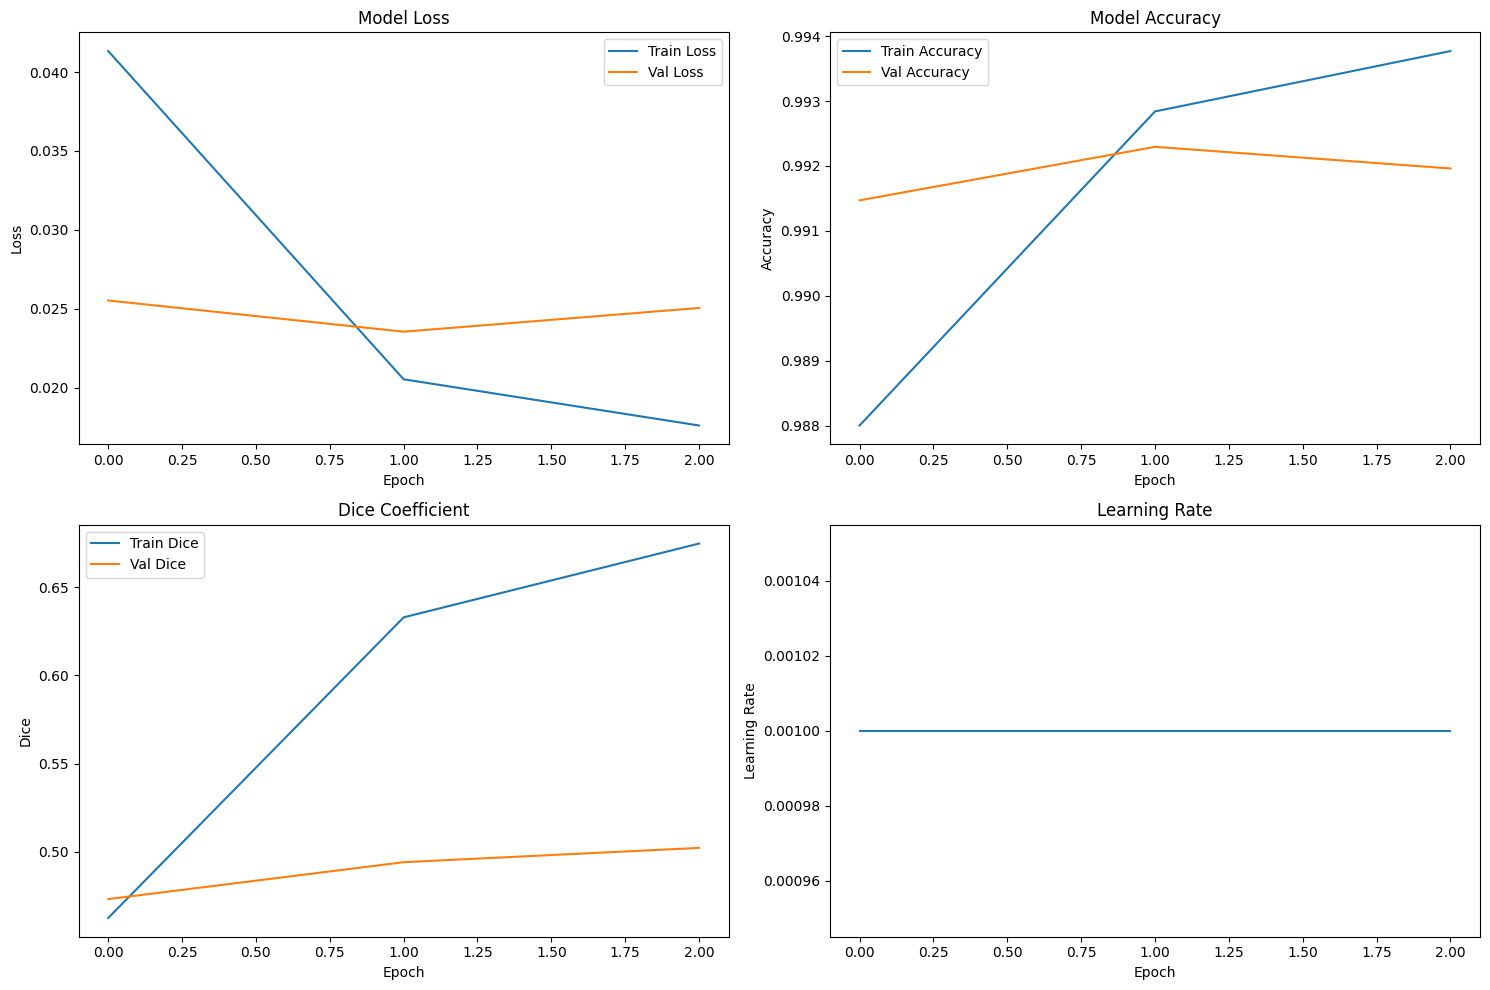

In [23]:
def plot_training_history(history):
    """Plot training curves"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0, 0].plot(history['train_loss'], label='Train Loss')
    axes[0, 0].plot(history['val_loss'], label='Val Loss')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    
    # Accuracy
    axes[0, 1].plot(history['train_accuracy'], label='Train Accuracy')
    axes[0, 1].plot(history['val_accuracy'], label='Val Accuracy')
    axes[0, 1].set_title('Model Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    
    # Dice Coefficient
    axes[1, 0].plot(history['train_dice_coef'], label='Train Dice')
    axes[1, 0].plot(history['val_dice_coef'], label='Val Dice')
    axes[1, 0].set_title('Dice Coefficient')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Dice')
    axes[1, 0].legend()
    
    # Learning Rate
    axes[1, 1].plot(history['learning_rate'])
    axes[1, 1].set_title('Learning Rate')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot training history
plot_training_history(history)

### Visualize model's predictions

In [24]:
def imageLoader(path):
    """Load and return NIfTI image data"""
    image = nib.load(path).get_fdata()
    return np.array(image)

def loadDataFromDir(path, list_of_files, mriType, n_images):
    """
    Load data from directory for multiple files
    """
    scans = []
    masks = []
    
    for i in list_of_files[:n_images]:
        # Find the file with the specified MRI type
        fullPath = glob.glob(i + '/*' + mriType + '*')[0]
        currentScanVolume = imageLoader(fullPath)
        currentMaskVolume = imageLoader(glob.glob(i + '/*seg*')[0])
        
        # For each slice in 3D volume, find also its mask
        for j in range(0, currentScanVolume.shape[2]):
            scan_img = cv2.resize(currentScanVolume[:, :, j], dsize=(IMG_SIZE, IMG_SIZE), 
                                interpolation=cv2.INTER_AREA).astype('uint8')
            mask_img = cv2.resize(currentMaskVolume[:, :, j], dsize=(IMG_SIZE, IMG_SIZE), 
                                interpolation=cv2.INTER_AREA).astype('uint8')
            scans.append(scan_img[..., np.newaxis])
            masks.append(mask_img[..., np.newaxis])
    
    return np.array(scans, dtype='float32'), np.array(masks, dtype='float32')

def predictByPath(case_path, case, model, device):
    """
    Predict segmentation for a single case using PyTorch model
    
    Args:
        case_path: Path to the case directory
        case: Case identifier
        model: PyTorch model
        device: Device to run inference on
    
    Returns:
        Predictions as numpy array
    """
    # Prepare input tensor
    X = np.empty((VOLUME_SLICES, IMG_SIZE, IMG_SIZE, 2))
    
    # Load FLAIR
    vol_path = os.path.join(case_path, f'BraTS20_Training_{case}_flair.nii')
    flair = nib.load(vol_path).get_fdata()
    
    # Load T1CE
    vol_path = os.path.join(case_path, f'BraTS20_Training_{case}_t1ce.nii')
    ce = nib.load(vol_path).get_fdata()
    
    # Process each slice
    for j in range(VOLUME_SLICES):
        X[j, :, :, 0] = cv2.resize(flair[:, :, j + VOLUME_START_AT], (IMG_SIZE, IMG_SIZE))
        X[j, :, :, 1] = cv2.resize(ce[:, :, j + VOLUME_START_AT], (IMG_SIZE, IMG_SIZE))
    
    # Normalize
    X_max = np.max(X)
    if X_max > 0:
        X = X / X_max
    
    # Convert to PyTorch tensor and change dimension order
    # From (VOLUME_SLICES, H, W, C) to (VOLUME_SLICES, C, H, W)
    X_tensor = torch.FloatTensor(X).permute(0, 3, 1, 2).to(device)
    
    # Set model to evaluation mode
    model.eval()
    
    # Predict
    with torch.no_grad():
        predictions = model(X_tensor)
        # Apply softmax to get probabilities
        predictions = F.softmax(predictions, dim=1)
    
    # Convert back to numpy and change dimension order
    # From (VOLUME_SLICES, C, H, W) to (VOLUME_SLICES, H, W, C)
    predictions_np = predictions.cpu().permute(0, 2, 3, 1).numpy()
    
    return predictions_np

def predictSingleSlice(flair_slice, t1ce_slice, model, device):
    """
    Predict segmentation for a single slice pair
    
    Args:
        flair_slice: FLAIR image slice
        t1ce_slice: T1CE image slice
        model: PyTorch model
        device: Device to run inference on
    
    Returns:
        Prediction for single slice
    """
    # Prepare input
    X = np.stack([flair_slice, t1ce_slice], axis=-1)  # (H, W, 2)
    X = X[np.newaxis, ...]  # Add batch dimension: (1, H, W, 2)
    
    # Normalize
    X_max = np.max(X)
    if X_max > 0:
        X = X / X_max
    
    # Convert to tensor and rearrange dimensions
    X_tensor = torch.FloatTensor(X).permute(0, 3, 1, 2).to(device)  # (1, 2, H, W)
    
    model.eval()
    with torch.no_grad():
        prediction = model(X_tensor)
        prediction = F.softmax(prediction, dim=1)
    
    # Convert back to numpy
    prediction_np = prediction.cpu().permute(0, 2, 3, 1).numpy()[0]  # Remove batch dim
    
    return prediction_np

def showPredictsById(case, model, device, start_slice=60):
    """
    Display predictions for a specific case
    
    Args:
        case: Case identifier (last 3 digits)
        model: Trained PyTorch model
        device: Device for inference
        start_slice: Starting slice index for visualization
    """
    # Construct paths
    path = f"/kaggle/input/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/BraTS20_Training_{case}"
    
    # Load ground truth and original image
    # seg_files = glob.glob(os.path.join(path, "*seg*.nii")) + \
    #     glob.glob(os.path.join(path, "*Segm*.nii"))
    # gt = seg_files[0]
    gt = nib.load(os.path.join(path, f'BraTS20_Training_{case}_seg.nii')).get_fdata()
    origImage = nib.load(os.path.join(path, f'BraTS20_Training_{case}_flair.nii')).get_fdata()
    
    # Get predictions
    p = predictByPath(path, case, model, device)
    
    # Extract different classes
    core = p[:, :, :, 1]
    edema = p[:, :, :, 2]
    enhancing = p[:, :, :, 3]
    
    # Create visualization
    plt.figure(figsize=(18, 50))
    f, axarr = plt.subplots(1, 6, figsize=(18, 50))
    
    # Add brain background to all subplots
    brain_bg = cv2.resize(origImage[:, :, start_slice + VOLUME_START_AT], (IMG_SIZE, IMG_SIZE))
    for i in range(6):
        axarr[i].imshow(brain_bg, cmap="gray", interpolation='none')
    
    # Original image
    axarr[0].imshow(brain_bg, cmap="gray")
    axarr[0].set_title('Original image flair')
    
    # Ground truth
    curr_gt = cv2.resize(gt[:, :, start_slice + VOLUME_START_AT], (IMG_SIZE, IMG_SIZE), 
                        interpolation=cv2.INTER_NEAREST)
    axarr[1].imshow(curr_gt, cmap="Reds", interpolation='none', alpha=0.3)
    axarr[1].set_title('Ground truth')
    
    # All classes predicted
    axarr[2].imshow(p[start_slice, :, :, 1:4], cmap="Reds", interpolation='none', alpha=0.3)
    axarr[2].set_title('All classes predicted')
    
    # Individual class predictions
    axarr[3].imshow(edema[start_slice, :, :], cmap="OrRd", interpolation='none', alpha=0.3)
    axarr[3].set_title(f'{SEGMENT_CLASSES[1]} predicted')
    
    axarr[4].imshow(core[start_slice, :, :], cmap="OrRd", interpolation='none', alpha=0.3)
    axarr[4].set_title(f'{SEGMENT_CLASSES[2]} predicted')
    
    axarr[5].imshow(enhancing[start_slice, :, :], cmap="OrRd", interpolation='none', alpha=0.3)
    axarr[5].set_title(f'{SEGMENT_CLASSES[3]} predicted')
    
    plt.show()

<Figure size 1800x5000 with 0 Axes>

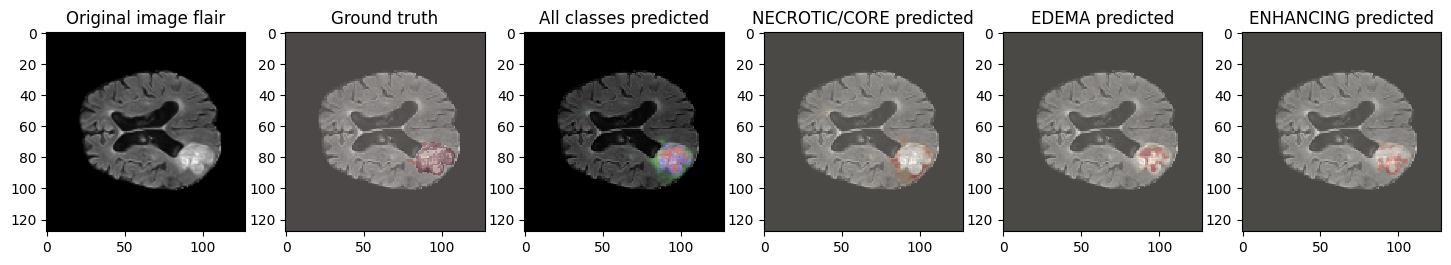

In [42]:
showPredictsById(case=test_patients[0][-3:], model=model, device=device)

<Figure size 1800x5000 with 0 Axes>

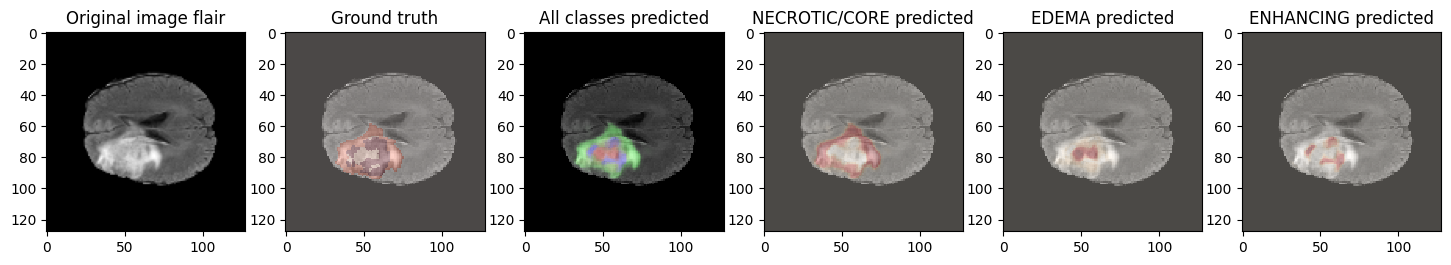

In [44]:
showPredictsById(case=test_patients[1][-3:], model=model, device=device)

<Figure size 1800x5000 with 0 Axes>

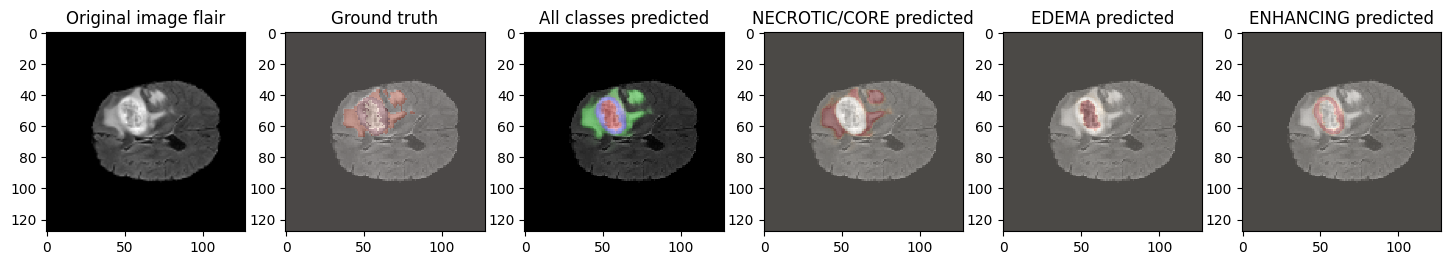

In [49]:
showPredictsById(case=test_patients[2][-3:], model=model, device=device)